<a href="https://colab.research.google.com/github/wingated/cs473/blob/main/mini_labs/week_4_empirical_risk.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# BYU CS 473 — Empirical Risk Minimization and Model Evaluation

In this assignment, you will learn how empirical risk minimization relates to model performance, and how concepts like approximation error, estimation error, regularization, structural risk minimization, and cross-validation help build better models.

---

## Learning Goals
- Understand **approximation error** vs **estimation error**
- Understand **regularized risk minimization**
- Understand **structural risk minimization**
- Apply **cross-validation** to evaluate models


## 1. Empirical Risk & Error Decomposition

- **Empirical Risk Minimization (ERM):** we choose a hypothesis that minimizes the average loss on training data.  
- **Approximation Error:** error due to limited model class (e.g., linear models can’t fit curved patterns).  
- **Estimation Error:** error due to limited data or overfitting.

$\text{Total Error} = \text{Approximation Error} + \text{Estimation Error}$


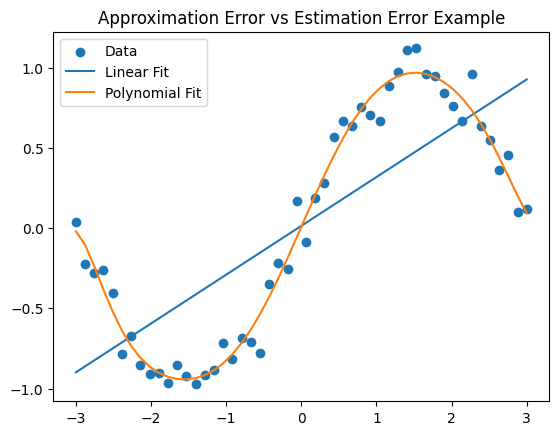

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error

# Generate nonlinear data
np.random.seed(0)
X = np.linspace(-3, 3, 50).reshape(-1, 1)
y = np.sin(X) + np.random.normal(0, 0.1, X.shape)

# Linear fit (high approx. error, low est. error)
lin = LinearRegression().fit(X, y)
y_lin = lin.predict(X)

# Polynomial fit (low approx. error, higher est. error risk)
poly = PolynomialFeatures(degree=10)
X_poly = poly.fit_transform(X)
lin_poly = LinearRegression().fit(X_poly, y)
y_poly = lin_poly.predict(X_poly)

plt.scatter(X, y, label="Data")
plt.plot(X, y_lin, label="Linear Fit")
plt.plot(X, y_poly, label="Polynomial Fit")
plt.legend()
plt.title("Approximation Error vs Estimation Error Example")
plt.show()


### Exercise 1
- Fit polynomial models of degree 2, 5, and 15 to the same data.  
- Compare their training error and test error (use a held-out test set).  
- Which models show more approximation error? Which show more estimation error?


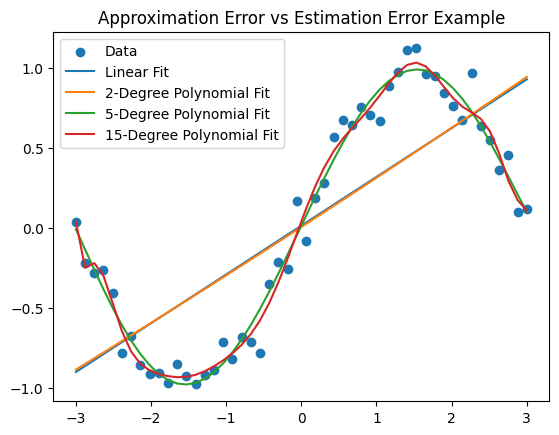

In [7]:
# Your code here
# Create test/train split.
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0
)

# 2-Degree Polynomial fit (low approx. error, higher est. error risk)
two_poly = PolynomialFeatures(degree=2)
X_train_two_poly = two_poly.fit_transform(X_train)
X_test_two_poly = two_poly.transform(X_test)
lin_two_poly = LinearRegression().fit(X_train_two_poly, y_train)

train_error_two_poly = mean_squared_error(y_train, lin_two_poly.predict(X_train_two_poly))
test_error_two_poly = mean_squared_error(y_test, lin_two_poly.predict(X_test_two_poly))

# 5-Degree Polynomial fit (low approx. error, higher est. error risk)
five_poly = PolynomialFeatures(degree=5)
X_train_five_poly = five_poly.fit_transform(X_train)
X_test_five_poly = five_poly.transform(X_test)
lin_five_poly = LinearRegression().fit(X_train_five_poly, y_train)

train_error_five_poly = mean_squared_error(y_train, lin_five_poly.predict(X_train_five_poly))
test_error_five_poly = mean_squared_error(y_test, lin_five_poly.predict(X_test_five_poly))

# Generate predictions (for plotting purposes -- I'm not sure if we need a plot).

# 15-Degree Polynomial fit (low approx. error, higher est. error risk)
fifteen_poly = PolynomialFeatures(degree=15)
X_train_fifteen_poly = fifteen_poly.fit_transform(X_train)
X_test_fifteen_poly = fifteen_poly.transform(X_test)
lin_fifteen_poly = LinearRegression().fit(X_train_fifteen_poly, y_train)

train_error_fifteen_poly = mean_squared_error(y_train, lin_fifteen_poly.predict(X_train_fifteen_poly))
test_error_fifteen_poly = mean_squared_error(y_test, lin_fifteen_poly.predict(X_test_fifteen_poly))

plt.scatter(X, y, label="Data")
plt.plot(X, y_lin, label="Linear Fit")
plt.plot(X, y_two_poly, label="2-Degree Polynomial Fit")
plt.plot(X, y_five_poly, label="5-Degree Polynomial Fit")
plt.plot(X, y_fifteen_poly, label="15-Degree Polynomial Fit")
plt.legend()
plt.title("Approximation Error vs Estimation Error Example")
plt.show()

# **FIX**

1. The _____ models show more approximation error.  This is because... .

2. The ______ models show more estimation error.  This is because... .

## 2. Regularized Risk

To reduce overfitting, we add a penalty term to the empirical risk:

$R_{\text{reg}}(h) = R_{\text{emp}}(h) + \lambda \cdot \Omega(h)$

- $R_{\text{emp}}$: training error  
- $\Omega(h)$: complexity of hypothesis (e.g., large weights)  
- $\lambda$: regularization strength  

Examples: **Ridge (L2)**, **Lasso (L1)**.


In [3]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_poly, y, test_size=0.3, random_state=0)

ridge = Ridge(alpha=1.0).fit(X_train, y_train)
lasso = Lasso(alpha=0.1, max_iter=10000).fit(X_train, y_train)

print("Ridge test error:", mean_squared_error(y_test, ridge.predict(X_test)))
print("Lasso test error:", mean_squared_error(y_test, lasso.predict(X_test)))

Ridge test error: 0.015494279161805081
Lasso test error: 0.055022128422353586


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.740e-02, tolerance: 1.728e-03
  model = cd_fast.enet_coordinate_descent(


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_poly, y, test_size=0.3, random_state=0)

ridge = Ridge(alpha=1.0).fit(X_train, y_train)
lasso = Lasso(alpha=0.1, max_iter=10000).fit(X_train, y_train)

print("Ridge test error:", mean_squared_error(y_test, ridge.predict(X_test)))
print("Lasso test error:", mean_squared_error(y_test, lasso.predict(X_test)))

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_poly, y, test_size=0.3, random_state=0)

ridge = Ridge(alpha=1.0).fit(X_train, y_train)
lasso = Lasso(alpha=0.1, max_iter=10000).fit(X_train, y_train)

print("Ridge test error:", mean_squared_error(y_test, ridge.predict(X_test)))
print("Lasso test error:", mean_squared_error(y_test, lasso.predict(X_test)))

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_poly, y, test_size=0.3, random_state=0)

ridge = Ridge(alpha=1.0).fit(X_train, y_train)
lasso = Lasso(alpha=0.1, max_iter=10000).fit(X_train, y_train)

print("Ridge test error:", mean_squared_error(y_test, ridge.predict(X_test)))
print("Lasso test error:", mean_squared_error(y_test, lasso.predict(X_test)))

### Exercise 2
Experiment with different values of λ for Ridge regression.  
- How does increasing λ affect training error?  
- How does it affect test error?  
- Why?


# **FIX**

1. Increasing $\lambda$ affects the training error by... .  This is because... .

2. Increasing $\lambda$ affects test error by... .  This is because.. .

3. These two impacts occur because... .

## 3. Structural Risk Minimization

ERM chooses the best hypothesis within a model class.  
**Structural Risk Minimization (SRM)** considers a sequence of model classes of increasing complexity, balancing fit and capacity.

- Small models → high approximation error, low estimation error.  
- Large models → low approximation error, high estimation error risk.  

SRM chooses the model class with best **generalization**.


### Exercise 3
Train polynomial regressors with degrees from 1 to 15.  
- Plot training and test error against model degree.  
- Which degree minimizes test error?  
- How does this illustrate SRM?


In [4]:
# Your code here
degrees = np.arange(1, 16, 1)

# Train polynomial regressors with degrees from 1-15.


# **FIX**

1. The _____-degree polynomial regressor minimizes test set error.  This occurs because... .

2. The effect responded to above illustrates SRM by... .

## 4. Cross-Validation

Cross-validation estimates model performance by splitting data into multiple training/test folds.

- **k-fold cross-validation:** split data into k folds, train on k-1, test on 1, rotate.  
- Provides a more stable estimate of generalization error.  


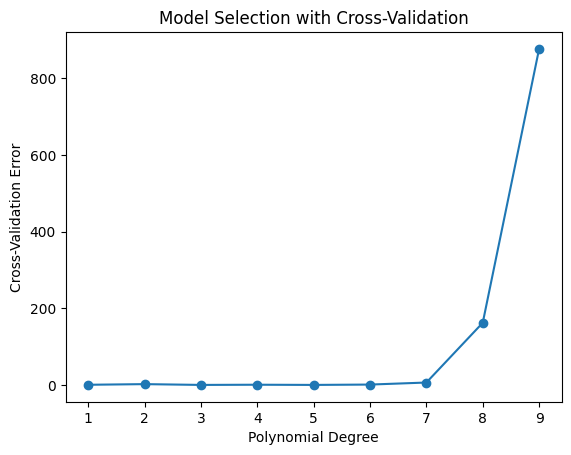

In [5]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline

degrees = range(1, 10)
cv_scores = []

for d in degrees:
    model = make_pipeline(PolynomialFeatures(d), LinearRegression())
    scores = cross_val_score(model, X, y, cv=5, scoring="neg_mean_squared_error")
    cv_scores.append(-scores.mean())

plt.plot(degrees, cv_scores, marker="o")
plt.xlabel("Polynomial Degree")
plt.ylabel("Cross-Validation Error")
plt.title("Model Selection with Cross-Validation")
plt.show()

### Exercise 4
- Which polynomial degree minimizes cross-validation error?  
- How does this compare to training/test error without cross-validation?  
- Why is cross-validation more reliable?

# **FIX**

1. The 1-degree polynomial minimizes cross-validation error (assuming the visualized approximately exponential growth in cross-validation error holds throughout the plotted domain).  This compares to the training/test error without cross-validation by... .

2. Cross-validation is more reliable because... .

## 5. Reflection

### Exercise 5
Answer in 2–3 sentences each:

1. What is the difference between approximation error and estimation error?  
2. How does regularization reduce overfitting?  
3. Why is cross-validation preferred over a single train/test split?


1. Whereas approximation error measures...

2. Regularization reduces overfitting by... .

3. Cross-validation is preferred over a single train/test split because... .